# Data Exploration

## 1. Data Loading

In [2]:
from tdc.single_pred import Tox
from tdc.multi_pred.dti import DTI  
from tdc.utils import retrieve_label_name_list

DATA_PATH = '../data'

# ============================================================
# TOXICITY DATASETS (core focus of the project)
# ============================================================

# 1. AMES — 7,255 molecules ★ START HERE
# Does this drug cause DNA mutations? (cancer risk)
# Binary classification. Clean, well-studied, good size for GNNs.
data_ames = Tox(name='AMES', path=DATA_PATH)
split_ames = data_ames.get_split()

# 2. hERG_Karim — 13,445 molecules
# Does this drug block the heart's hERG potassium channel? (fatal arrhythmia risk)
# Binary classification. Largest single-target toxicity dataset here.
data_herg = Tox(name='hERG_Karim', path=DATA_PATH)
split_herg = data_herg.get_split()

# 3. ClinTox — 1,484 molecules
# Did this drug fail clinical trials due to toxicity, or get FDA approved?
# Binary classification. Real-world outcome, not a lab assay.
data_clintox = Tox(name='ClinTox', path=DATA_PATH)
split_clintox = data_clintox.get_split()

# 4. Tox21 — 7,831 molecules × 12 targets
# US government screen across 12 toxicity pathways (nuclear receptors, stress response).
# We load only the FIRST of the 12 tasks (label_list[0]) — single binary classification, not multi-label.
label_list = retrieve_label_name_list('Tox21')
data_tox21 = Tox(name='Tox21', label_name=label_list[0], path=DATA_PATH)
split_tox21 = data_tox21.get_split()

# 5. DILI — 475 molecules
# Does this drug cause liver injury? #1 reason drugs get pulled from market.
# Binary classification. Very small — might be too tiny for GNNs.
data_dili = Tox(name='DILI', path=DATA_PATH)
split_dili = data_dili.get_split()

# 6. LD50_Zhu — 7,385 molecules
# What dose kills 50% of test organisms? (acute toxicity)
# Regression, not classification. Predict a continuous log-dose value.
data_ld50 = Tox(name='LD50_Zhu', path=DATA_PATH)
split_ld50 = data_ld50.get_split()

# ============================================================
# BINDING SELECTIVITY DATASETS (stretch goal per proposal)
# ============================================================

# 7. DAVIS — 30,056 drug-target pairs (68 drugs × 442 kinase targets)
# How strongly does this drug bind to each kinase protein?
# Regression (Kd affinity). Same drugs across many targets = selectivity data.
# Trains on CPU in ~30-60 min.
data_davis = DTI(name='DAVIS', path=DATA_PATH)
split_davis = data_davis.get_split()

# 8. KIBA — 118,254 drug-target pairs (2,111 drugs × 229 targets)
# Same idea as DAVIS but much larger. Probably needs a GPU.
# Only use if DAVIS feels too small.
data_kiba = DTI(name='KIBA', path=DATA_PATH)
split_kiba = data_kiba.get_split()

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


In [3]:
from rdkit import Chem
from torch_geometric.data import Data
import torch

def smiles_to_graph(smiles):
    """Convert SMILES to a PyG graph. Atom features: 9-dim vector."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),             # element identity (C=6, N=7, O=8…)
            atom.GetDegree(),                # number of bonds
            atom.GetFormalCharge(),          # +1 / 0 / -1
            int(atom.GetIsAromatic()),       # in aromatic ring?
            atom.GetTotalNumHs(),            # attached hydrogens
            int(atom.IsInRing()),            # in any ring?
            int(atom.GetHybridization()),    # SP=2, SP2=3, SP3=4…
            atom.GetTotalValence(),          # total valence
            atom.GetNumRadicalElectrons(),   # radical electrons (usually 0)
        ])

    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]

    x          = torch.tensor(atom_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

# Sanity check
smiles = split_ames['train']['Drug'].iloc[0]
g = smiles_to_graph(smiles)
print(f"Graph: {g}  →  {g.num_node_features} atom features")

Graph: Data(x=[23, 9], edge_index=[2, 54])  →  9 atom features


## 2. Molecular Graph Representation

Done


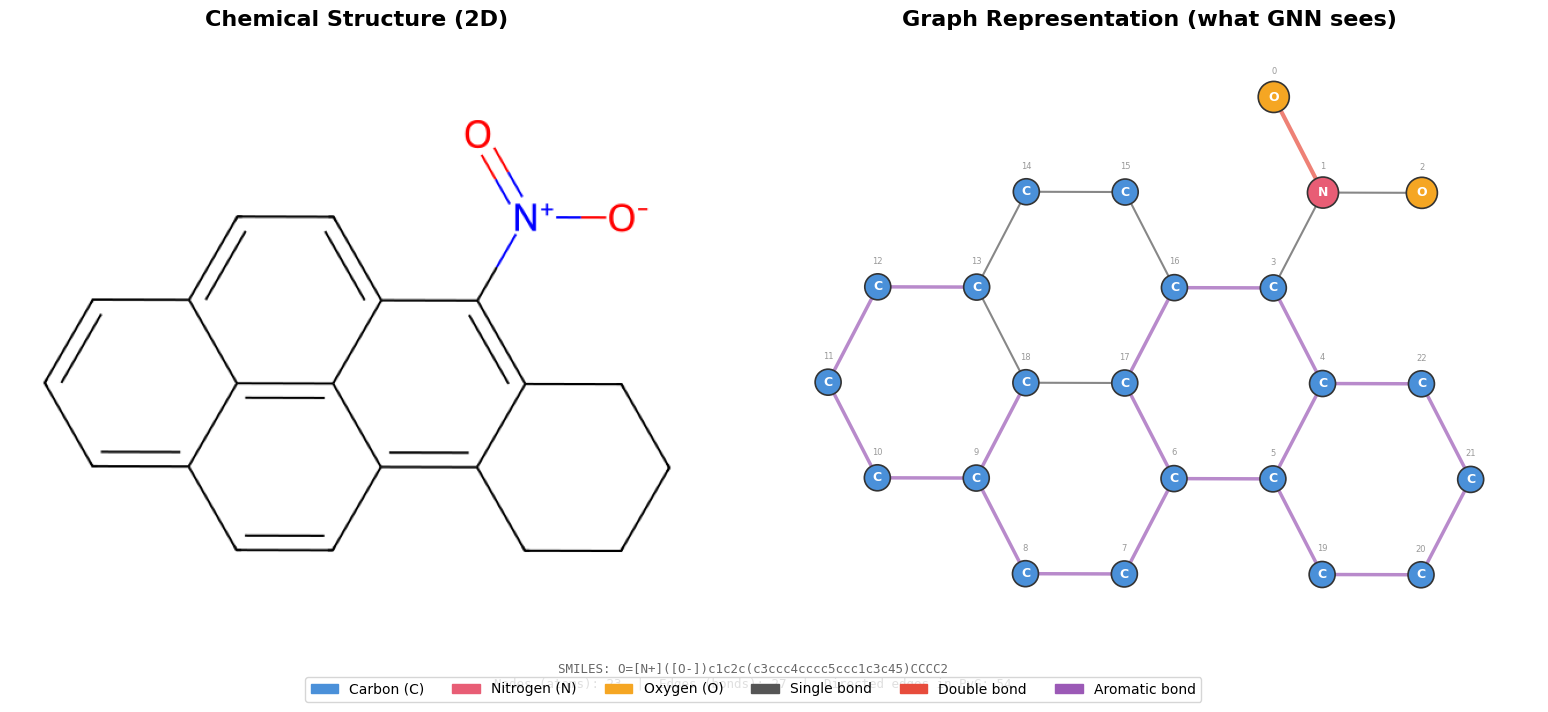

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

mol = Chem.MolFromSmiles(smiles)
AllChem.Compute2DCoords(mol)

# Build networkx graph from molecule
G = nx.Graph()
conf = mol.GetConformer()

atom_colors_map = {6: '#4A90D9', 7: '#E85D75', 8: '#F5A623', 16: '#F7DC6F', 9: '#82E0AA', 17: '#82E0AA'}
atom_labels_map = {6: 'C', 7: 'N', 8: 'O', 16: 'S', 9: 'F', 17: 'Cl'}
bond_style_map = {Chem.rdchem.BondType.SINGLE: '-', Chem.rdchem.BondType.DOUBLE: '=', Chem.rdchem.BondType.AROMATIC: '~'}

node_colors = []
node_labels = {}
node_sizes = []

for atom in mol.GetAtoms():
    idx = atom.GetIdx()
    num = atom.GetAtomicNum()
    pos = conf.GetAtomPosition(idx)
    G.add_node(idx, pos=(pos.x, pos.y))
    node_colors.append(atom_colors_map.get(num, '#CCCCCC'))
    node_labels[idx] = atom_labels_map.get(num, atom.GetSymbol())
    node_sizes.append(500 if num != 6 else 350)

edge_colors = []
edge_widths = []
for bond in mol.GetBonds():
    i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    bt = bond.GetBondType()
    G.add_edge(i, j)
    if bt == Chem.rdchem.BondType.DOUBLE:
        edge_colors.append('#E74C3C')
        edge_widths.append(3.0)
    elif bt == Chem.rdchem.BondType.AROMATIC:
        edge_colors.append('#9B59B6')
        edge_widths.append(2.5)
    else:
        edge_colors.append('#555555')
        edge_widths.append(1.5)

pos = nx.get_node_attributes(G, 'pos')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# Left: chemical structure
img = Draw.MolToImage(mol, size=(600, 500))
axes[0].imshow(img)
axes[0].set_title('Chemical Structure (2D)', fontsize=16, fontweight='bold', pad=15)
axes[0].axis('off')

# Right: graph representation
ax = axes[1]
ax.set_facecolor('#FAFAFA')

nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths, alpha=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors='#333333', linewidths=1.2)
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=9, font_weight='bold', font_color='white')

# Node index labels (small, offset)
offset_pos = {k: (v[0], v[1] + 0.35) for k, v in pos.items()}
idx_labels = {i: str(i) for i in G.nodes()}
nx.draw_networkx_labels(G, offset_pos, labels=idx_labels, ax=ax, font_size=6, font_color='#999999')

ax.set_title('Graph Representation (what GNN sees)', fontsize=16, fontweight='bold', pad=15)
ax.axis('off')

# Legend
legend_items = [
    mpatches.Patch(color='#4A90D9', label='Carbon (C)'),
    mpatches.Patch(color='#E85D75', label='Nitrogen (N)'),
    mpatches.Patch(color='#F5A623', label='Oxygen (O)'),
    mpatches.Patch(color='#555555', label='Single bond'),
    mpatches.Patch(color='#E74C3C', label='Double bond'),
    mpatches.Patch(color='#9B59B6', label='Aromatic bond'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=6, fontsize=10,
           frameon=True, facecolor='white', edgecolor='#CCCCCC', bbox_to_anchor=(0.5, -0.02))

# Stats annotation
stats_text = (
    f"SMILES: {smiles}\n"
    f"Nodes (atoms): {mol.GetNumAtoms()}  |  "
    f"Edges (bonds): {mol.GetNumBonds()}  |  "
    f"Directed edges in PyG: {mol.GetNumBonds() * 2}"
)
fig.text(0.5, 0.01, stats_text, ha='center', fontsize=9, color='#666666', family='monospace')

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.savefig('../plots/mol_graph.png', dpi=200, bbox_inches='tight', facecolor='white')
print("Done")

## 3. Model Architectures

Four GNN variants are implemented and compared:
- **GCN** — Graph Convolutional Network (Kipf & Welling, 2017)
- **GIN** — Graph Isomorphism Network (Xu et al., 2019) — theoretically most expressive
- **GAT** — Graph Attention Network (Veličković et al., 2018)
- **GraphSAGE** — Inductive representation learning (Hamilton et al., 2017)

All models: 2 conv layers, hidden dim = 16, global pooling → linear classifier/regressor.

In [5]:
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x.squeeze(-1)

In [6]:
from torch_geometric.nn import GINConv, global_add_pool
from torch.nn import Sequential, Linear, BatchNorm1d, ReLU

class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(
                Linear(in_channels, hidden_channels), 
                BatchNorm1d(hidden_channels), 
                ReLU(), 
                Linear(hidden_channels, hidden_channels), 
                ReLU())
        )
        self.conv2 = GINConv(
            Sequential(
                Linear(hidden_channels, hidden_channels), 
                BatchNorm1d(hidden_channels), 
                ReLU(), 
                Linear(hidden_channels, hidden_channels), 
                ReLU()
            )
        )
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = global_add_pool(x, batch)
        x = self.lin(x)
        return x.squeeze(-1)

In [7]:
from torch_geometric.nn import GATConv, global_mean_pool
import torch.nn.functional as F
from torch.nn import Linear

class GATGraph(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.2)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=0.2)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = global_mean_pool(x, batch)  # graph-level representation
        x = self.lin(x)
        return x.squeeze(-1)

In [8]:
from torch_geometric.nn import SAGEConv, global_mean_pool
import torch.nn.functional as F
from torch.nn import Linear

class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)   # graph-level representation
        x = self.lin(x)
        return x.squeeze(-1)

In [9]:
import copy
import json
import os
import random
import traceback
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             mean_squared_error, precision_score, recall_score,
                             roc_auc_score, r2_score)
from torch.utils.tensorboard import SummaryWriter
from torch_geometric.loader import DataLoader

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Version — increment for each new experiment ───────────────────────────────
# v1: 4 atom features, hidden=16, lr=0.01, unweighted BCE
# v2: 9 atom features, hidden=64, lr=0.001, class-weighted BCE
VERSION = 'v2'

HIDDEN_DIM    = 64
LEARNING_RATE = 0.001

BASE_DIR    = Path('..')
RESULTS_DIR = BASE_DIR / 'results' / VERSION
MODELS_DIR  = BASE_DIR / 'models'  / VERSION
PLOTS_DIR   = BASE_DIR / 'plots'   / VERSION
TB_DIR      = BASE_DIR / 'results' / VERSION / 'tensorboard'
for path in [RESULTS_DIR, MODELS_DIR, PLOTS_DIR, TB_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Version : {VERSION}")
print(f"Hidden  : {HIDDEN_DIM}  |  LR: {LEARNING_RATE}")
print(f"Results → {RESULTS_DIR.resolve()}")

Device: cuda
Version : v2
Hidden  : 64  |  LR: 0.001
Results → C:\Users\Tzagkari\Desktop\Coding\Τεχνητή Νοημοσύνη ΑΠΘ\2ο Εξάμηνο\Προχωρημένα Θέματα Μηχανικής Μάθησης\Project-KGX\results\v2


In [10]:
# ── Dataset configs ──────────────────────────────────────────────────────────
DATASET_CONFIGS = [
    {'name': 'AMES',       'split': split_ames,    'task': 'classification', 'max_epochs': 200, 'patience': 25, 'batch_size': 32},
    {'name': 'hERG_Karim', 'split': split_herg,    'task': 'classification', 'max_epochs': 220, 'patience': 25, 'batch_size': 32},
    {'name': 'ClinTox',    'split': split_clintox, 'task': 'classification', 'max_epochs': 180, 'patience': 20, 'batch_size': 16},
    {'name': 'DILI',       'split': split_dili,    'task': 'classification', 'max_epochs': 140, 'patience': 18, 'batch_size': 16},
    {'name': 'LD50_Zhu',   'split': split_ld50,    'task': 'regression',     'max_epochs': 220, 'patience': 25, 'batch_size': 32},
]

# Expand Tox21 into all 12 binary tasks
print(f"Expanding Tox21 into {len(label_list)} tasks...")
for tox21_label in label_list:
    tox21_data = Tox(name='Tox21', label_name=tox21_label, path=DATA_PATH)
    DATASET_CONFIGS.append({
        'name': f'Tox21_{tox21_label}', 'split': tox21_data.get_split(),
        'task': 'classification', 'max_epochs': 200, 'patience': 22, 'batch_size': 32,
    })

MODEL_CLASSES = [GCN, GIN, GATGraph, GraphSAGEModel]
print(f"Total: {len(DATASET_CONFIGS)} datasets × {len(MODEL_CLASSES)} models = {len(DATASET_CONFIGS)*len(MODEL_CLASSES)} runs")

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...


Expanding Tox21 into 12 tasks...


Done!


Total: 17 datasets × 4 models = 68 runs


In [11]:
# ── Data pipeline helpers ─────────────────────────────────────────────────────
def build_graph_dataset(df):
    graphs = []
    for _, row in df.iterrows():
        g = smiles_to_graph(row['Drug'])
        if g is None or 'Y' not in row:
            continue
        g.y = torch.tensor([row['Y']], dtype=torch.float)
        graphs.append(g)
    return graphs

def get_loaders(split_data, batch_size=32):
    train_graphs = build_graph_dataset(split_data['train'])
    val_graphs   = build_graph_dataset(split_data['valid'])
    test_graphs  = build_graph_dataset(split_data['test'])
    if not (train_graphs and val_graphs and test_graphs):
        raise ValueError(f"Empty split: train={len(train_graphs)}, val={len(val_graphs)}, test={len(test_graphs)}")
    return (
        DataLoader(train_graphs, batch_size=batch_size, shuffle=True, drop_last=True),
        DataLoader(val_graphs,   batch_size=batch_size),
        DataLoader(test_graphs,  batch_size=batch_size),
        train_graphs, val_graphs, test_graphs,
    )

# ── Metric helpers ─────────────────────────────────────────────────────────────
def compute_classification_metrics(labels, probs):
    labels = np.asarray(labels).ravel()
    probs  = np.asarray(probs).ravel()
    preds  = (probs >= 0.5).astype(int)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'roc_auc':   roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float('nan'),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }

def compute_regression_metrics(labels, preds):
    labels = np.asarray(labels).ravel()
    preds  = np.asarray(preds).ravel()
    return {
        'mae':  mean_absolute_error(labels, preds),
        'rmse': float(np.sqrt(mean_squared_error(labels, preds))),
        'r2':   r2_score(labels, preds),
    }

In [12]:
# ── Training loop (single model on single dataset) ────────────────────────────
def train_one_model(model_cls, train_loader, val_loader, test_loader, task, device, in_channels,
                    max_epochs=200, patience=20, lr=LEARNING_RATE, writer=None, min_delta=1e-4):
    model     = model_cls(in_channels, HIDDEN_DIM, 1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # Class-weighted loss for imbalanced classification — pos_weight = neg/pos ratio.
    # This tells the model to penalise missing a toxic molecule more heavily than a false alarm.
    if task == 'classification':
        all_y  = torch.cat([b.y for b in train_loader]).view(-1)
        n_pos  = max(all_y.sum().item(), 1)
        n_neg  = len(all_y) - n_pos
        pw     = torch.tensor([n_neg / n_pos], device=device)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pw)
        print(f"  pos_weight={pw.item():.2f}  (neg/pos={n_neg:.0f}/{n_pos:.0f})")
    else:
        criterion = torch.nn.MSELoss()

    if writer is None:
        writer = SummaryWriter(str(TB_DIR / 'auto_run')); close_writer = True
    else:
        close_writer = False

    history       = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state    = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running, n = 0.0, 0
        for batch in train_loader:
            batch = batch.to(device); optimizer.zero_grad()
            out   = model(batch.x, batch.edge_index, batch.batch)
            loss  = criterion(out, batch.y.view(-1))
            loss.backward(); optimizer.step()
            running += loss.item() * batch.num_graphs; n += batch.num_graphs
        epoch_train = running / max(n, 1)
        history['train_loss'].append(epoch_train)

        model.eval(); running, n = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out   = model(batch.x, batch.edge_index, batch.batch)
                running += criterion(out, batch.y.view(-1)).item() * batch.num_graphs
                n += batch.num_graphs
        epoch_val = running / max(n, 1)
        history['val_loss'].append(epoch_val)

        writer.add_scalar('loss/train', epoch_train, epoch)
        writer.add_scalar('loss/val',   epoch_val,   epoch)
        writer.add_scalar('lr', optimizer.param_groups[0]['lr'], epoch)

        if epoch_val + min_delta < best_val_loss:
            best_val_loss = epoch_val; best_state = copy.deepcopy(model.state_dict()); patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step(epoch_val)
        if epoch % 20 == 0 or patience_counter == 1:
            print(f"  Epoch {epoch:3d}  train={epoch_train:.4f}  val={epoch_val:.4f}  patience={patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"  Early stop at epoch {epoch}."); break

    model.load_state_dict(best_state)
    if close_writer: writer.close()

    # ── Test evaluation ───────────────────────────────────────────────────────
    model.eval()
    preds_list, labels_list, test_loss, n = [], [], 0.0, 0
    with torch.no_grad():
        for batch in test_loader:
            batch  = batch.to(device)
            out    = model(batch.x, batch.edge_index, batch.batch)
            target = batch.y.view(-1)
            test_loss += criterion(out, target).item() * batch.num_graphs; n += batch.num_graphs
            raw = torch.sigmoid(out) if task == 'classification' else out
            preds_list.append(raw.cpu().numpy()); labels_list.append(target.cpu().numpy())

    test_loss /= max(n, 1)
    probs  = np.concatenate(preds_list)
    labels = np.concatenate(labels_list)
    scores = compute_classification_metrics(labels, probs) if task == 'classification' \
             else compute_regression_metrics(labels, probs)

    return model, test_loss, scores, history

In [13]:
# ── Run all experiments ───────────────────────────────────────────────────────
all_results = []

for config in DATASET_CONFIGS:
    dataset_name = config['name']
    split_data, task = config['split'], config['task']
    print(f"\n=== {dataset_name} ({task}) ===")

    dataset_dir = MODELS_DIR / dataset_name
    dataset_dir.mkdir(parents=True, exist_ok=True)
    dataset_results = []

    try:
        train_loader, val_loader, test_loader, train_graphs, val_graphs, test_graphs = \
            get_loaders(split_data, batch_size=config['batch_size'])
    except Exception as exc:
        print(f"  Loader failed: {exc}"); traceback.print_exc(); continue

    in_channels = train_graphs[0].num_node_features
    for model_cls in MODEL_CLASSES:
        model_name = model_cls.__name__
        model_path = dataset_dir / f"{model_name}.pt"
        tb_run_dir = TB_DIR / dataset_name / model_name
        tb_run_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n  -- {model_name}")
        writer = SummaryWriter(str(tb_run_dir))
        try:
            model, test_loss, scores, history = train_one_model(
                model_cls, train_loader, val_loader, test_loader, task, device, in_channels,
                max_epochs=config['max_epochs'], patience=config['patience'], lr=0.01, writer=writer,
            )
            writer.close()
            torch.save(model.state_dict(), model_path)

            result = {'dataset': dataset_name, 'model': model_name, 'task': task,
                      'test_loss': float(test_loss), **scores}
            all_results.append(result); dataset_results.append(result)

            with open(dataset_dir / f"{model_name}.json", 'w') as f:
                json.dump({'dataset': dataset_name, 'model': model_name, 'task': task,
                           'model_path': str(model_path), 'history': history, 'scores': scores}, f, indent=2)
        except Exception as exc:
            print(f"  Error: {exc}"); traceback.print_exc(); writer.close(); continue

    if dataset_results:
        pd.DataFrame(dataset_results).to_csv(RESULTS_DIR / f"{dataset_name}_results.csv", index=False)

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv(RESULTS_DIR / 'all_model_results.csv', index=False)
all_results_df.to_csv(RESULTS_DIR / 'all_model_results_summary.csv', index=False)
print('\nAll training complete.')
display(all_results_df)


=== AMES (classification) ===

  -- GCN
  pos_weight=0.85  (neg/pos=2332/2756)
  Epoch   2  train=0.6038  val=0.6125  patience=1/25
  Epoch   7  train=0.5825  val=0.5794  patience=1/25
  Epoch  10  train=0.5787  val=0.5775  patience=1/25
  Epoch  19  train=0.5730  val=0.5568  patience=1/25
  Epoch  20  train=0.5750  val=0.5623  patience=2/25
  Epoch  32  train=0.5654  val=0.5535  patience=1/25
  Epoch  36  train=0.5657  val=0.5484  patience=1/25
  Epoch  40  train=0.5656  val=0.5606  patience=5/25
  Epoch  45  train=0.5651  val=0.5516  patience=1/25
  Epoch  49  train=0.5643  val=0.5523  patience=1/25
  Epoch  55  train=0.5627  val=0.5486  patience=1/25
  Epoch  60  train=0.5629  val=0.5446  patience=0/25
  Epoch  61  train=0.5647  val=0.5517  patience=1/25
  Epoch  64  train=0.5628  val=0.5425  patience=1/25
  Epoch  72  train=0.5642  val=0.5414  patience=1/25
  Epoch  77  train=0.5636  val=0.5458  patience=1/25
  Epoch  80  train=0.5585  val=0.5575  patience=4/25
  Epoch  83  train=

[14:19:19] WARNING: not removing hydrogen atom without neighbors
[14:19:20] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:19:20] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:19:20] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:19:21] Explicit valence for atom # 20 Al, 6, is greater than permitted
[14:19:21] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:19:21] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:19:21] Explicit valence for atom # 5 Al, 6, is greater than permitted



  -- GCN
  pos_weight=23.66  (neg/pos=4851/205)
  Epoch   5  train=1.1351  val=1.1584  patience=1/22
  Epoch  12  train=1.0662  val=1.1698  patience=1/22
  Epoch  16  train=1.0789  val=1.0978  patience=1/22
  Epoch  19  train=1.0418  val=1.1154  patience=1/22
  Epoch  20  train=1.0517  val=1.0974  patience=2/22
  Epoch  32  train=1.0221  val=1.0869  patience=1/22
  Epoch  40  train=0.9986  val=1.0764  patience=9/22
  Epoch  48  train=0.9974  val=1.0743  patience=1/22
  Epoch  51  train=1.0112  val=1.0745  patience=1/22
  Epoch  58  train=0.9968  val=1.1167  patience=1/22
  Epoch  60  train=0.9965  val=1.0765  patience=3/22
  Epoch  63  train=0.9891  val=1.1069  patience=1/22
  Epoch  75  train=0.9927  val=1.0969  patience=1/22
  Epoch  79  train=0.9908  val=1.0838  patience=1/22
  Epoch  80  train=0.9918  val=1.0806  patience=2/22
  Epoch  96  train=0.9911  val=1.0708  patience=1/22
  Epoch 100  train=0.9894  val=1.0870  patience=5/22
  Epoch 107  train=0.9884  val=1.0908  patience=1/

[14:30:32] WARNING: not removing hydrogen atom without neighbors
[14:30:33] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:30:33] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:30:33] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:30:33] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:30:33] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:30:34] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:30:35] Explicit valence for atom # 20 Al, 6, is greater than permitted



  -- GCN
  pos_weight=25.73  (neg/pos=4528/176)
  Epoch   5  train=1.0185  val=1.1637  patience=1/22
  Epoch   8  train=1.0974  val=1.0359  patience=1/22
  Epoch  10  train=1.0340  val=0.9465  patience=1/22
  Epoch  15  train=0.9604  val=0.8357  patience=1/22
  Epoch  18  train=0.9635  val=0.8556  patience=1/22
  Epoch  20  train=0.9419  val=0.8929  patience=3/22
  Epoch  24  train=0.9484  val=0.8281  patience=1/22
  Epoch  26  train=0.9447  val=0.8134  patience=1/22
  Epoch  33  train=0.9573  val=0.8348  patience=1/22
  Epoch  40  train=0.9420  val=0.8134  patience=8/22
  Epoch  54  train=0.9197  val=0.8549  patience=1/22
  Epoch  60  train=0.9105  val=0.7789  patience=7/22
  Epoch  67  train=0.8888  val=0.7981  patience=1/22
  Epoch  80  train=0.8829  val=0.7785  patience=14/22
  Epoch  87  train=0.8867  val=0.7795  patience=1/22
  Epoch 100  train=0.8770  val=0.7767  patience=14/22
  Epoch 107  train=0.8812  val=0.7820  patience=1/22
  Epoch 115  train=0.8743  val=0.7800  patience=

...

[16:16:44] WARNING: not removing hydrogen atom without neighbors
[16:16:44] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:16:44] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:16:44] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:16:44] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:16:45] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:16:45] Explicit valence for atom # 20 Al, 6, is greater than permitted



  -- GCN
  pos_weight=5.44  (neg/pos=3406/626)
  Epoch   2  train=1.0784  val=1.2856  patience=1/22
  Epoch   6  train=1.0627  val=1.1493  patience=1/22
  Epoch   9  train=1.0531  val=1.1736  patience=1/22
  Epoch  11  train=1.0484  val=1.2074  patience=1/22
  Epoch  14  train=1.0358  val=1.1353  patience=1/22
  Epoch  16  train=1.0203  val=1.1218  patience=1/22
  Epoch  19  train=1.0340  val=1.0929  patience=1/22
  Epoch  20  train=1.0206  val=1.0302  patience=0/22
  Epoch  21  train=1.0054  val=1.0848  patience=1/22
  Epoch  23  train=0.9989  val=1.0521  patience=1/22
  Epoch  26  train=1.0316  val=1.0978  patience=1/22
  Epoch  34  train=0.9938  val=1.0191  patience=1/22
  Epoch  36  train=0.9895  val=1.0009  patience=1/22
  Epoch  40  train=0.9944  val=1.0057  patience=5/22
  Epoch  48  train=0.9739  val=1.0060  patience=1/22
  Epoch  52  train=0.9685  val=0.9857  patience=1/22
  Epoch  54  train=0.9657  val=0.9932  patience=1/22
  Epoch  59  train=0.9573  val=1.0393  patience=1/2

[16:33:08] Explicit valence for atom # 3 Al, 6, is greater than permitted
[16:33:08] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:33:09] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:33:09] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:33:09] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:33:09] Explicit valence for atom # 20 Al, 6, is greater than permitted
[16:33:09] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:33:10] WARNING: not removing hydrogen atom without neighbors



  -- GCN
  pos_weight=14.43  (neg/pos=4429/307)
  Epoch   4  train=1.1975  val=1.1184  patience=1/22
  Epoch   6  train=1.1951  val=1.1221  patience=1/22
  Epoch  11  train=1.1897  val=1.1281  patience=1/22
  Epoch  15  train=1.1555  val=1.0711  patience=1/22
  Epoch  20  train=1.1708  val=1.2043  patience=6/22
  Epoch  23  train=1.1459  val=1.0632  patience=1/22
  Epoch  40  train=1.1134  val=1.0777  patience=18/22
  Early stop at epoch 44.

  -- GIN
  pos_weight=14.43  (neg/pos=4429/307)
  Epoch   2  train=1.1641  val=1.2001  patience=1/22
  Epoch   6  train=1.0979  val=1.3546  patience=1/22
  Epoch  20  train=1.0095  val=1.1958  patience=15/22
  Early stop at epoch 27.

  -- GATGraph
  pos_weight=14.43  (neg/pos=4429/307)
  Epoch   3  train=1.2785  val=1.1254  patience=1/22
  Epoch   9  train=1.2519  val=1.1562  patience=1/22
  Epoch  20  train=1.2320  val=1.2666  patience=12/22
  Epoch  30  train=1.2062  val=1.1299  patience=1/22
  Epoch  34  train=1.1725  val=1.1215  patience=1/2

,dataset,model,task,test_loss,accuracy,roc_auc,precision,recall,f1,mae,rmse,r2
0,AMES,GCN,classification,0.548347,0.666896,0.738183,0.704042,0.676692,0.690096,NaN,NaN,NaN
1,AMES,GIN,classification,0.440014,0.780220,0.850780,0.814474,0.775689,0.794608,NaN,NaN,NaN
2,AMES,GATGraph,classification,0.492807,0.731456,0.805687,0.746667,0.771930,0.759088,NaN,NaN,NaN
3,AMES,GraphSAGEModel,classification,0.490313,0.729396,0.808852,0.773713,0.715539,0.743490,NaN,NaN,NaN
4,hERG_Karim,GCN,classification,0.691886,0.500558,0.577150,0.000000,0.000000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
63,Tox21_SR-MMP,GraphSAGEModel,classification,0.898988,0.745690,0.826328,0.354592,0.767956,0.485166,NaN,NaN,NaN
64,Tox21_SR-p53,GCN,classification,1.029121,0.758672,0.771190,0.141618,0.620253,0.230588,NaN,NaN,NaN
65,Tox21_SR-p53,GIN,classification,1.018023,0.853875,0.810851,0.203980,0.518987,0.292857,NaN,NaN,NaN
66,Tox21_SR-p53,GATGraph,classification,0.996740,0.752768,0.781735,0.144444,0.658228,0.236902,NaN,NaN,NaN


## 4. Training

Trains all 4 architectures on all 17 datasets (5 toxicity + 12 Tox21 endpoints).
Uses early stopping on validation loss, ReduceLROnPlateau scheduler, seed=42 for reproducibility.
Saves model weights to `../models/` and metrics to `../results/`.

## 5. Results Analysis

Change `VERSION` at the top of the next cell to switch between experiment runs.
- `'v1'` — baseline (4 features, hidden=16, lr=0.01)
- `'v2'` — improved (9 features, hidden=64, class-weighted loss, lr=0.001)

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Loading results from: C:\Users\Tzagkari\Desktop\Coding\Τεχνητή Νοημοσύνη ΑΠΘ\2ο Εξάμηνο\Προχωρημένα Θέματα Μηχανικής Μάθησης\Project-KGX\results\v2
Loading class-imbalance ratios...


Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Done.



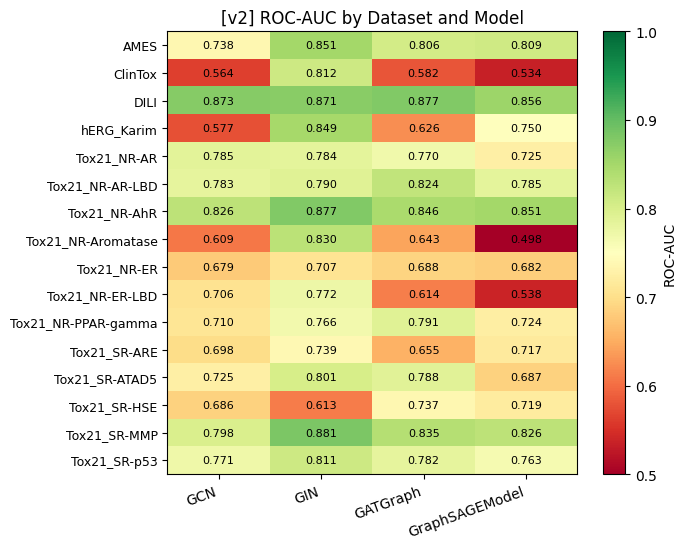

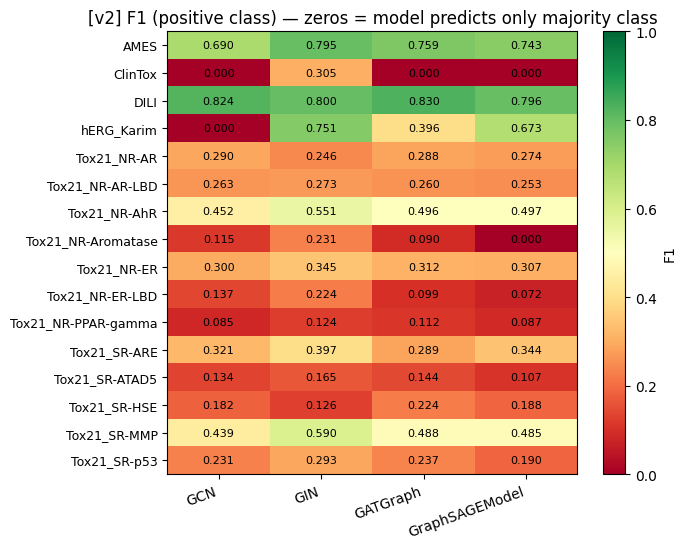

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tdc.single_pred import Tox
from tdc.utils import retrieve_label_name_list

# ── Change this to switch experiment version ───────────────────────────────────
VERSION = 'v2'   # 'v1' = baseline | 'v2' = improved

RESULTS_DIR = Path('..') / 'results' / VERSION
PLOTS_DIR   = Path('..') / 'plots'   / VERSION
DATA_PATH   = '../data'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Loading results from: {RESULTS_DIR.resolve()}")
df  = pd.read_csv(RESULTS_DIR / 'all_model_results_summary.csv')
clf = df[df['task'] == 'classification'].copy()
reg = df[df['task'] == 'regression'].copy()

MODEL_ORDER  = ['GCN', 'GIN', 'GATGraph', 'GraphSAGEModel']
MODEL_COLORS = {'GCN': '#4A90D9', 'GIN': '#E85D75', 'GATGraph': '#F5A623', 'GraphSAGEModel': '#82E0AA'}
non_tox  = sorted([d for d in clf['dataset'].unique() if not d.startswith('Tox21_')])
tox_ds   = sorted([d for d in clf['dataset'].unique() if     d.startswith('Tox21_')])
ds_order = non_tox + tox_ds

# ── Class imbalance ratios (cached TDC data) ──────────────────────────────────
print("Loading class-imbalance ratios...")
imbalance = {}
for name in ['AMES', 'hERG_Karim', 'ClinTox', 'DILI']:
    sp = Tox(name=name, path=DATA_PATH).get_split()
    imbalance[name] = pd.concat(sp.values())['Y'].mean()
for label in retrieve_label_name_list('Tox21'):
    sp = Tox(name='Tox21', label_name=label, path=DATA_PATH).get_split()
    imbalance[f'Tox21_{label}'] = pd.concat(sp.values())['Y'].mean()
imb_df = pd.DataFrame({'dataset': list(imbalance.keys()), 'pos_ratio': list(imbalance.values())})
print("Done.\n")

# ── Reusable heatmap helper ───────────────────────────────────────────────────
def annotated_heatmap(matrix, title, cbar_label, cmap, vmin, vmax, savepath, fmt='.3f'):
    fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(matrix.index))))
    im = ax.imshow(matrix.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=9)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, format(v, fmt), ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_title(f"[{VERSION}] {title}"); plt.tight_layout()
    plt.savefig(savepath, dpi=200, bbox_inches='tight'); plt.show()

# ── ROC-AUC heatmap ───────────────────────────────────────────────────────────
roc = clf.pivot(index='dataset', columns='model', values='roc_auc').reindex(ds_order)[MODEL_ORDER]
annotated_heatmap(roc, 'ROC-AUC by Dataset and Model', 'ROC-AUC',
                  'RdYlGn', 0.5, 1.0, PLOTS_DIR / 'roc_auc_heatmap.png')

# ── F1 heatmap ────────────────────────────────────────────────────────────────
f1 = clf.pivot(index='dataset', columns='model', values='f1').reindex(ds_order)[MODEL_ORDER]
annotated_heatmap(f1, 'F1 (positive class) — zeros = model predicts only majority class',
                  'F1', 'RdYlGn', 0.0, 1.0, PLOTS_DIR / 'f1_heatmap.png')

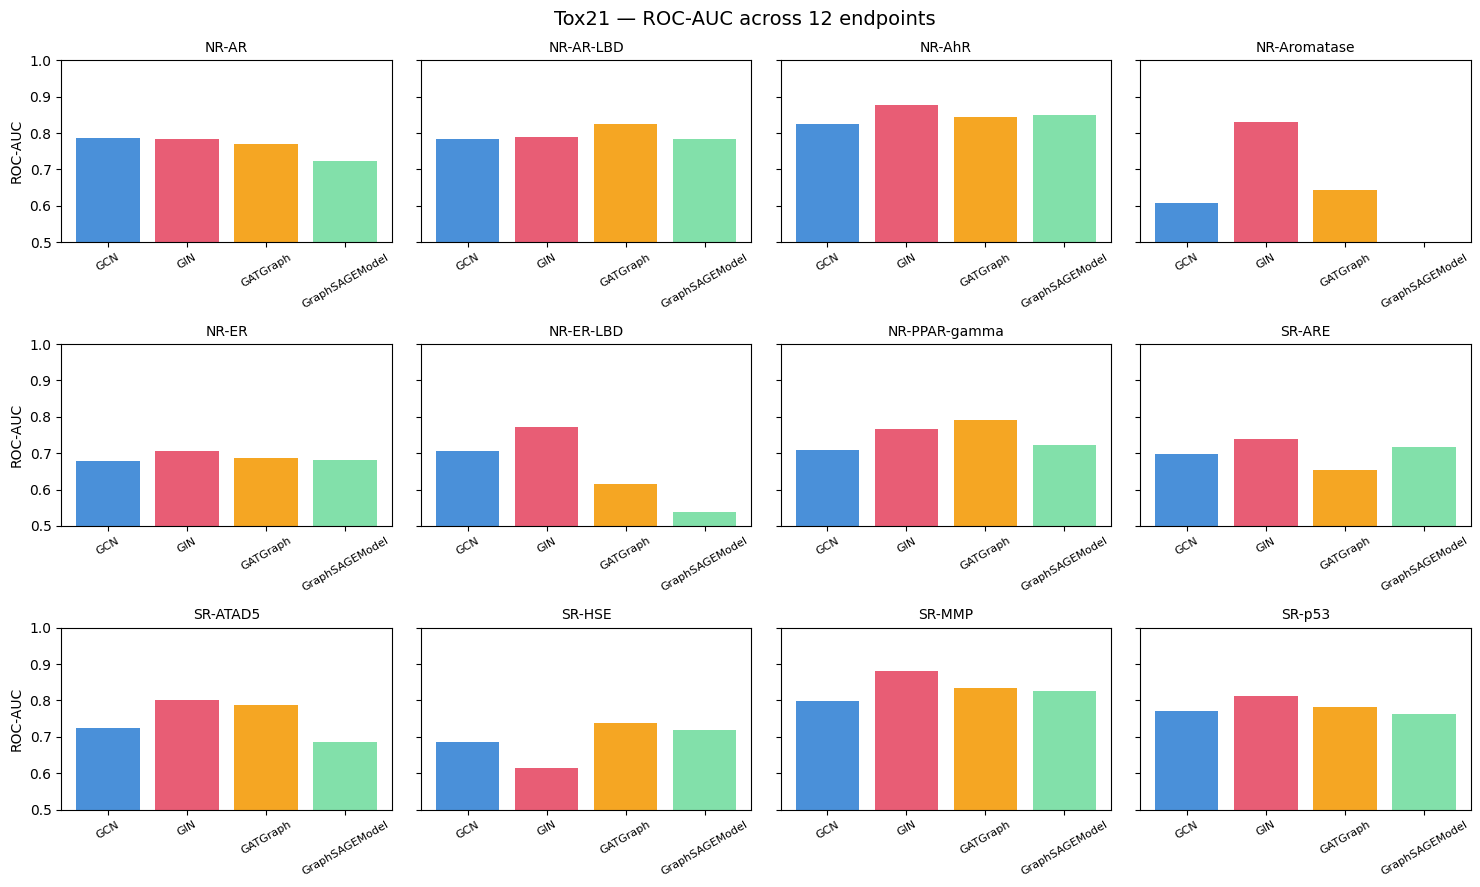

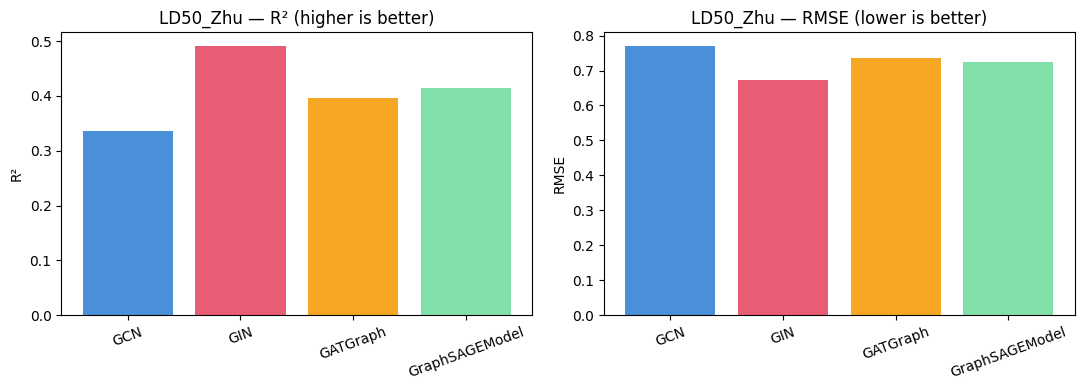

In [15]:
# ── Tox21 small multiples (12 endpoints) ─────────────────────────────────────
tox_clf = clf[clf['dataset'].str.startswith('Tox21_')]
tasks   = sorted(tox_clf['dataset'].unique())

fig, axes = plt.subplots(3, 4, figsize=(15, 9), sharey=True)
for ax, task in zip(axes.flat, tasks):
    sub = tox_clf[tox_clf['dataset'] == task].set_index('model').reindex(MODEL_ORDER)
    ax.bar(MODEL_ORDER, sub['roc_auc'], color=[MODEL_COLORS[m] for m in MODEL_ORDER])
    ax.set_title(task.replace('Tox21_', ''), fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.6)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel('ROC-AUC')
fig.suptitle('Tox21 — ROC-AUC across 12 endpoints', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tox21_panel.png', dpi=200, bbox_inches='tight')
plt.show()

# ── LD50 regression: R² and RMSE ─────────────────────────────────────────────
reg_sub = reg.set_index('model').reindex(MODEL_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(MODEL_ORDER, reg_sub['r2'],   color=[MODEL_COLORS[m] for m in MODEL_ORDER])
axes[0].set_title('LD50_Zhu — R² (higher is better)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.6)
axes[0].set_ylabel('R²')
axes[1].bar(MODEL_ORDER, reg_sub['rmse'], color=[MODEL_COLORS[m] for m in MODEL_ORDER])
axes[1].set_title('LD50_Zhu — RMSE (lower is better)')
axes[1].set_ylabel('RMSE')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ld50_regression.png', dpi=200, bbox_inches='tight')
plt.show()

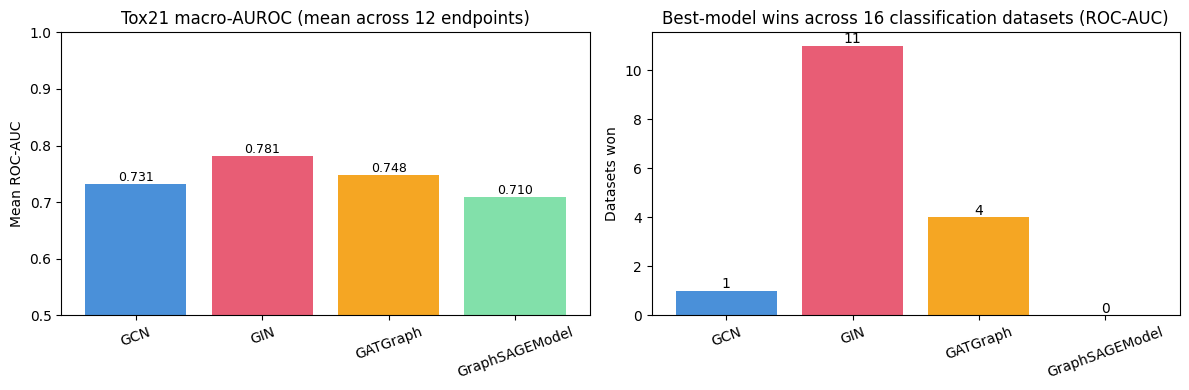

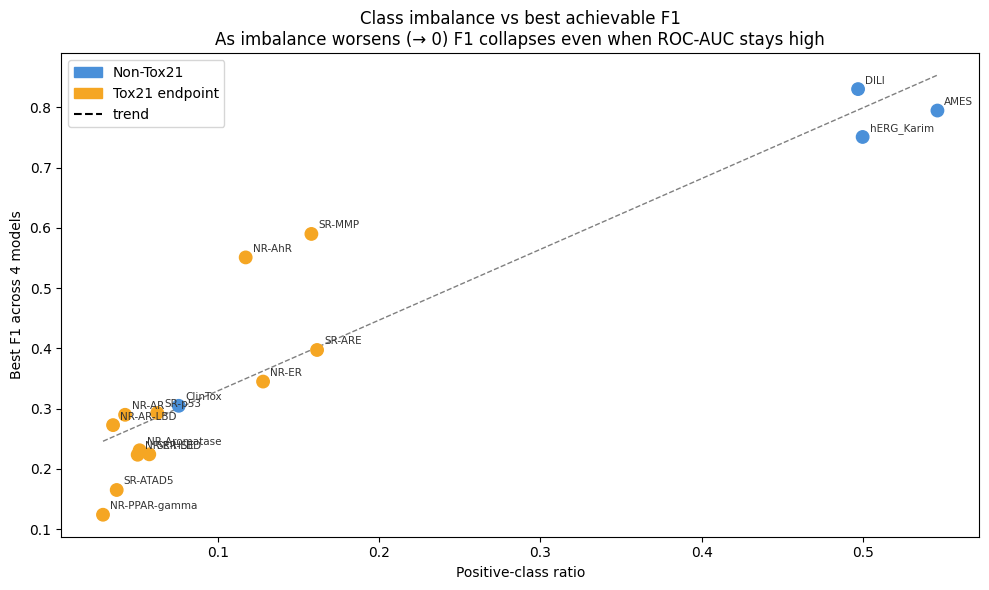

=== Best model per dataset (ROC-AUC) ===
                        model   roc_auc        f1
dataset                                          
AMES                      GIN  0.850780  0.794608
ClinTox                   GIN  0.811657  0.304762
DILI                 GATGraph  0.877216  0.830189
hERG_Karim                GIN  0.848988  0.750774
Tox21_NR-AR               GCN  0.785283  0.289855
Tox21_NR-AR-LBD      GATGraph  0.823888  0.260000
Tox21_NR-AhR              GIN  0.877376  0.550943
Tox21_NR-Aromatase        GIN  0.829948  0.230986
Tox21_NR-ER               GIN  0.707062  0.344954
Tox21_NR-ER-LBD           GIN  0.771531  0.223565
Tox21_NR-PPAR-gamma  GATGraph  0.790537  0.112150
Tox21_SR-ARE              GIN  0.739170  0.397373
Tox21_SR-ATAD5            GIN  0.801086  0.165094
Tox21_SR-HSE         GATGraph  0.737006  0.224242
Tox21_SR-MMP              GIN  0.881125  0.589899
Tox21_SR-p53              GIN  0.810851  0.292857

=== Win counts ===
model
GCN                1
GIN         

In [16]:
# ── Tox21 macro-AUROC + win counts ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tox_macro = tox_clf.groupby('model')['roc_auc'].mean().reindex(MODEL_ORDER)
axes[0].bar(MODEL_ORDER, tox_macro.values, color=[MODEL_COLORS[m] for m in MODEL_ORDER])
axes[0].set_title('Tox21 macro-AUROC (mean across 12 endpoints)')
axes[0].set_ylabel('Mean ROC-AUC'); axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(tox_macro.values):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

winners    = clf.loc[clf.groupby('dataset')['roc_auc'].idxmax(), ['dataset', 'model']]
win_counts = winners['model'].value_counts().reindex(MODEL_ORDER, fill_value=0)
axes[1].bar(MODEL_ORDER, win_counts.values, color=[MODEL_COLORS[m] for m in MODEL_ORDER])
axes[1].set_title(f'Best-model wins across {len(ds_order)} classification datasets (ROC-AUC)')
axes[1].set_ylabel('Datasets won')
for i, v in enumerate(win_counts.values):
    axes[1].text(i, v + 0.1, str(int(v)), ha='center', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_summary.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Class imbalance vs best F1 scatter ───────────────────────────────────────
best_f1    = clf.groupby('dataset')['f1'].max().reset_index()
scatter_df = best_f1.merge(imb_df, on='dataset')

fig, ax = plt.subplots(figsize=(10, 6))
colors = scatter_df['dataset'].str.startswith('Tox21_').map({True: '#F5A623', False: '#4A90D9'})
ax.scatter(scatter_df['pos_ratio'], scatter_df['f1'], c=colors, s=80, zorder=3)
for _, row in scatter_df.iterrows():
    ax.annotate(row['dataset'].replace('Tox21_', ''),
                (row['pos_ratio'], row['f1']), textcoords='offset points',
                xytext=(5, 4), fontsize=7.5, color='#333333')
z = np.polyfit(scatter_df['pos_ratio'], scatter_df['f1'], 1)
xl = np.linspace(scatter_df['pos_ratio'].min(), scatter_df['pos_ratio'].max(), 100)
ax.plot(xl, np.polyval(z, xl), 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('Positive-class ratio'); ax.set_ylabel('Best F1 across 4 models')
ax.set_title('Class imbalance vs best achievable F1\n'
             'As imbalance worsens (→ 0) F1 collapses even when ROC-AUC stays high')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4A90D9', label='Non-Tox21'),
                   Patch(color='#F5A623', label='Tox21 endpoint'),
                   plt.Line2D([0],[0], color='k', linestyle='--', label='trend')])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'imbalance_vs_f1.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Summary tables ────────────────────────────────────────────────────────────
print("=== Best model per dataset (ROC-AUC) ===")
best = clf.loc[clf.groupby('dataset')['roc_auc'].idxmax(),
               ['dataset','model','roc_auc','f1']].set_index('dataset').reindex(ds_order)
print(best.to_string())
print("\n=== Win counts ==="); print(win_counts.to_string())
print("\n=== Tox21 macro-AUROC ==="); print(tox_macro.round(4).to_string())

## 6. Threshold Calibration

Re-evaluates every saved model using **threshold = positive-class ratio** per dataset instead of fixed 0.5.
Fixes the F1=0 collapse on heavily imbalanced endpoints (e.g. ClinTox ~8% positive, SR-ATAD5 ~4% positive).
Produces a side-by-side before/after F1 heatmap and saves `../results/calibrated_results.csv`.

In [17]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, mean_absolute_error,
                             mean_squared_error, precision_score, recall_score,
                             roc_auc_score, r2_score)
from tdc.single_pred import Tox
from tdc.utils import retrieve_label_name_list

# ── Change this to switch experiment version ───────────────────────────────────
VERSION = 'v2'   # 'v1' = baseline | 'v2' = improved

RESULTS_DIR = Path('..') / 'results' / VERSION
MODELS_DIR  = Path('..') / 'models'  / VERSION
DATA_PATH   = '../data'
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# HIDDEN_DIM must match whatever was used when VERSION was trained
HIDDEN_DIM_MAP = {'v1': 16, 'v2': 64}
_HIDDEN_DIM    = HIDDEN_DIM_MAP[VERSION]
print(f"Version: {VERSION}  |  hidden_dim: {_HIDDEN_DIM}")

# ── Positive-class ratios ─────────────────────────────────────────────────────
print("Computing class-imbalance ratios...")
imbalance = {}
for name in ['AMES', 'hERG_Karim', 'ClinTox', 'DILI']:
    sp = Tox(name=name, path=DATA_PATH).get_split()
    imbalance[name] = pd.concat(sp.values())['Y'].mean()
for label in retrieve_label_name_list('Tox21'):
    sp = Tox(name='Tox21', label_name=label, path=DATA_PATH).get_split()
    imbalance[f'Tox21_{label}'] = pd.concat(sp.values())['Y'].mean()
print(f"Done. Threshold range: {min(imbalance.values()):.3f} – {max(imbalance.values()):.3f}\n")

# ── Metric helpers ────────────────────────────────────────────────────────────
def clf_metrics(labels, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy':  accuracy_score(labels, preds),
        'roc_auc':   roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float('nan'),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }

def reg_metrics(labels, preds):
    return {
        'threshold': float('nan'),
        'mae':  mean_absolute_error(labels, preds),
        'rmse': float(np.sqrt(mean_squared_error(labels, preds))),
        'r2':   r2_score(labels, preds),
    }

# ── Re-evaluate all saved models with calibrated thresholds ──────────────────
calibrated_results = []

for config in DATASET_CONFIGS:
    dataset_name = config['name']
    task         = config['task']
    threshold    = imbalance.get(dataset_name, 0.5) if task == 'classification' else None
    label        = f"(thr={threshold:.3f})" if threshold else ""
    print(f"{dataset_name} {label}")

    try:
        _, _, test_loader, train_graphs, _, _ = get_loaders(config['split'], config['batch_size'])
    except Exception as e:
        print(f"  loader failed: {e}"); continue

    in_channels = train_graphs[0].num_node_features
    for model_cls in MODEL_CLASSES:
        model_name = model_cls.__name__
        model_path = MODELS_DIR / dataset_name / f"{model_name}.pt"
        if not model_path.exists():
            print(f"  {model_name}: no saved weights"); continue

        model = model_cls(in_channels, _HIDDEN_DIM, 1).to(device)
        model.load_state_dict(torch.load(str(model_path), map_location=device, weights_only=True))
        model.eval()

        preds_list, labels_list = [], []
        with torch.no_grad():
            for batch in test_loader:
                batch  = batch.to(device)
                out    = model(batch.x, batch.edge_index, batch.batch)
                raw    = torch.sigmoid(out) if task == 'classification' else out
                preds_list.append(raw.cpu().numpy())
                labels_list.append(batch.y.view(-1).cpu().numpy())

        probs  = np.concatenate(preds_list)
        labels = np.concatenate(labels_list)
        scores = clf_metrics(labels, probs, threshold) if task == 'classification' \
                 else reg_metrics(labels, probs)

        msg = f"F1={scores['f1']:.3f}  AUROC={scores['roc_auc']:.3f}" if task == 'classification' \
              else f"R²={scores['r2']:.3f}  RMSE={scores['rmse']:.3f}"
        print(f"  {model_name}: {msg}")

        calibrated_results.append({'dataset': dataset_name, 'model': model_name,
                                   'task': task, **scores})

cal_df = pd.DataFrame(calibrated_results)
cal_df.to_csv(RESULTS_DIR / 'calibrated_results.csv', index=False)
print(f"\nSaved → {RESULTS_DIR / 'calibrated_results.csv'}")

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Version: v2  |  hidden_dim: 64
Computing class-imbalance ratios...


Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Done. Threshold range: 0.029 – 0.546

AMES (thr=0.546)
  GCN: F1=0.650  AUROC=0.738
  GIN: F1=0.777  AUROC=0.851
  GATGraph: F1=0.733  AUROC=0.806
  GraphSAGEModel: F1=0.735  AUROC=0.809
hERG_Karim (thr=0.500)
  GCN: F1=0.000  AUROC=0.577
  GIN: F1=0.751  AUROC=0.849
  GATGraph: F1=0.456  AUROC=0.626
  GraphSAGEModel: F1=0.674  AUROC=0.750
ClinTox (thr=0.076)
  GCN: F1=0.150  AUROC=0.564
  GIN: F1=0.241  AUROC=0.812
  GATGraph: F1=0.150  AUROC=0.582
  GraphSAGEModel: F1=0.157  AUROC=0.534
DILI (thr=0.497)
  GCN: F1=0.824  AUROC=0.873
  GIN: F1=0.800  AUROC=0.871
  GATGraph: F1=0.830  AUROC=0.877
  GraphSAGEModel: F1=0.788  AUROC=0.856
LD50_Zhu 
  GCN: R²=0.335  RMSE=0.771
  GIN: R²=0.491  RMSE=0.674
  GATGraph: R²=0.396  RMSE=0.735
  GraphSAGEModel: R²=0.415  RMSE=0.723
Tox21_NR-AR (thr=0.043)


[16:39:35] WARNING: not removing hydrogen atom without neighbors
[16:39:36] Explicit valence for atom # 3 Al, 6, is greater than permitted
[16:39:36] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:39:36] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:39:36] Explicit valence for atom # 20 Al, 6, is greater than permitted
[16:39:37] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:39:37] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:39:37] Explicit valence for atom # 5 Al, 6, is greater than permitted


...

  GCN: F1=0.102  AUROC=0.686
  GIN: F1=0.102  AUROC=0.613
  GATGraph: F1=0.102  AUROC=0.737
  GraphSAGEModel: F1=0.102  AUROC=0.719
Tox21_SR-MMP (thr=0.158)


[16:40:04] WARNING: not removing hydrogen atom without neighbors
[16:40:04] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:40:04] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:40:05] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:40:05] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:40:05] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:40:05] Explicit valence for atom # 20 Al, 6, is greater than permitted


  GCN: F1=0.333  AUROC=0.798
  GIN: F1=0.412  AUROC=0.881
  GATGraph: F1=0.343  AUROC=0.835
  GraphSAGEModel: F1=0.338  AUROC=0.826
Tox21_SR-p53 (thr=0.062)


[16:40:07] Explicit valence for atom # 3 Al, 6, is greater than permitted
[16:40:07] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:40:07] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:40:07] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:40:08] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:40:08] Explicit valence for atom # 20 Al, 6, is greater than permitted
[16:40:08] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:40:08] WARNING: not removing hydrogen atom without neighbors


  GCN: F1=0.114  AUROC=0.771
  GIN: F1=0.110  AUROC=0.811
  GATGraph: F1=0.120  AUROC=0.782
  GraphSAGEModel: F1=0.113  AUROC=0.763

Saved → ..\results\v2\calibrated_results.csv


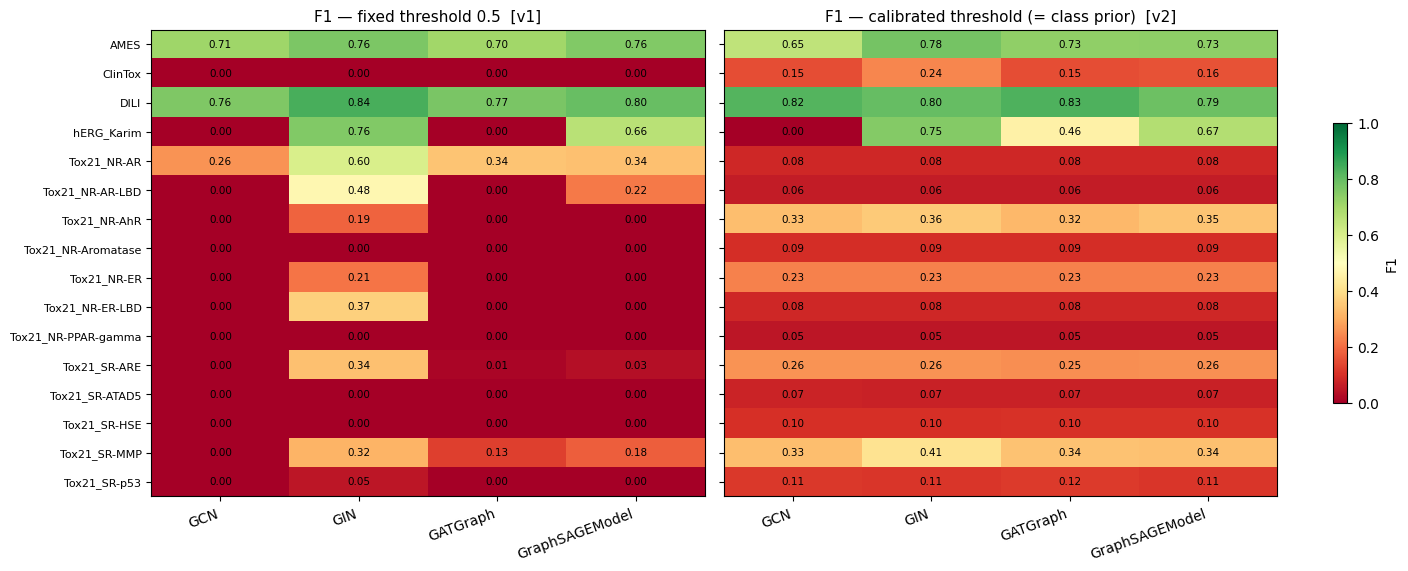

=== Mean F1 — v1 fixed 0.5  vs  v2 calibrated ===
                F1 v1 @0.5  F1 v2 @cal   gain
model                                        
GCN                  0.108       0.215  0.107
GIN                  0.307       0.280 -0.027
GATGraph             0.122       0.249  0.127
GraphSAGEModel       0.187       0.262  0.075


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# VERSION is inherited from the calibration cell above
RESULTS_DIR = Path('..') / 'results' / VERSION
PLOTS_DIR   = Path('..') / 'plots'   / VERSION
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

orig_df  = pd.read_csv(Path('..') / 'results' / 'all_model_results_summary.csv')  # v1 baseline
cal_df   = pd.read_csv(RESULTS_DIR / 'calibrated_results.csv')                    # current version
orig_clf = orig_df[orig_df['task'] == 'classification']
cal_clf  = cal_df[cal_df['task']  == 'classification']

MODEL_ORDER = ['GCN', 'GIN', 'GATGraph', 'GraphSAGEModel']
non_tox  = sorted([d for d in cal_clf['dataset'].unique() if not d.startswith('Tox21_')])
tox_ds   = sorted([d for d in cal_clf['dataset'].unique() if     d.startswith('Tox21_')])
ds_order = non_tox + tox_ds

f1_orig = orig_clf.pivot(index='dataset', columns='model', values='f1').reindex(ds_order)[MODEL_ORDER]
f1_cal  = cal_clf.pivot( index='dataset', columns='model', values='f1').reindex(ds_order)[MODEL_ORDER]

# ── Side-by-side F1: fixed 0.5 vs calibrated ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.35 * len(ds_order))),
                         sharey=True, constrained_layout=True)
for ax, matrix, title in zip(axes,
        [f1_orig, f1_cal],
        [f'F1 — fixed threshold 0.5  [v1]',
         f'F1 — calibrated threshold (= class prior)  [{VERSION}]']):
    im = ax.imshow(matrix.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(4)); ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right')
    ax.set_yticks(range(len(ds_order))); ax.set_yticklabels(ds_order, fontsize=8)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7.5)
    ax.set_title(title, fontsize=11)
fig.colorbar(im, ax=axes, label='F1', shrink=0.6)
plt.savefig(PLOTS_DIR / 'f1_calibrated_vs_fixed.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Mean F1 gain per model ────────────────────────────────────────────────────
print(f"=== Mean F1 — v1 fixed 0.5  vs  {VERSION} calibrated ===")
summary = pd.DataFrame({
    'F1 v1 @0.5':          orig_clf.groupby('model')['f1'].mean().reindex(MODEL_ORDER),
    f'F1 {VERSION} @cal':  cal_clf.groupby('model')['f1'].mean().reindex(MODEL_ORDER),
}).round(3)
summary['gain'] = (summary[f'F1 {VERSION} @cal'] - summary['F1 v1 @0.5']).round(3)
print(summary.to_string())

## 7. TensorBoard

Monitor training curves live. Run after section 4 has started.

In [19]:
%load_ext tensorboard
# VERSION is set in section 4 setup cell — update there to switch runs
%tensorboard --logdir ../results/v2/tensorboard --port 6006